# Examples using the WCS-based interface to *GroenMonitor*

**Author:** Bruno Marcos

**Created in:** February 19, 2026

## Settings

In [1]:
# Load packages
library(terra)
library(rNDC)

# Define parameters
myparams <- c(date = "20251225",
              xmin = 684613,
              xmax = 685907,
              ymin = 5763913,
              ymax = 5764822,
              format = "tiff")

terra 1.8.42


## 1. RGB

In [2]:
myurl <- gm_url(option = "RGB", params = myparams)
cat(myurl)

https://data.groenmonitor.nl/geoserver/wcs?service=WCS&version=2.0.1&request=GetCoverage&coverageId=groenmonitor__rgb_20251225&subset=E(684613,685907)&subset=N(5763913,5764822)&format=image/tiff

In [3]:
myfile <- file.path(tempdir(), "rgb_20251225.tif")
gm_get(url = myurl, out_path = myfile)

Response [https://data.groenmonitor.nl/geoserver/wcs?service=WCS&version=2.0.1&request=GetCoverage&coverageId=groenmonitor__rgb_20251225&subset=E(684613,685907)&subset=N(5763913,5764822)&format=image/tiff]
  Date: 2026-10-02 14:08
  Status: 200
  Content-Type: image/tiff
  Size: 74.1 kB
<ON DISK>  /tmp/RtmpxhmbDW/rgb_20251225.tif

In [4]:
mydata <- rast(myfile)
print(mydata)

class       : SpatRaster 
dimensions  : 91, 129, 3  (nrow, ncol, nlyr)
resolution  : 10, 10  (x, y)
extent      : 684610, 685900, 5763910, 5764820  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 31N (EPSG:32631) 
source      : rgb_20251225.tif 
colors RGB  : 1, 2, 3 
names       : rgb_20251225_1, rgb_20251225_2, rgb_20251225_3 


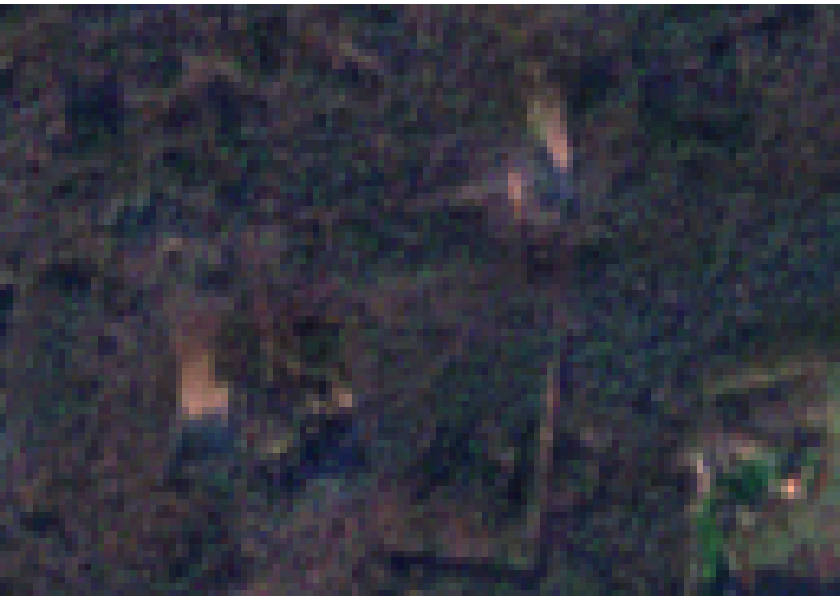

In [5]:
plot(mydata)

## 2. NDVI

In [6]:
myurl <- gm_url(option = "NDVI", params = myparams)
cat(myurl)

https://data.groenmonitor.nl/geoserver/wcs?service=WCS&version=2.0.1&request=GetCoverage&coverageId=groenmonitor__ndvi_20251225&subset=E(684613,685907)&subset=N(5763913,5764822)&format=image/tiff

In [7]:
myfile <- file.path(tempdir(), "ndvi_20251225.tif")
gm_get(url = myurl, out_path = myfile)

Response [https://data.groenmonitor.nl/geoserver/wcs?service=WCS&version=2.0.1&request=GetCoverage&coverageId=groenmonitor__ndvi_20251225&subset=E(684613,685907)&subset=N(5763913,5764822)&format=image/tiff]
  Date: 2026-10-02 14:08
  Status: 200
  Content-Type: image/tiff
  Size: 25 kB
<ON DISK>  /tmp/RtmpxhmbDW/ndvi_20251225.tif

In [8]:
mydata <- rast(myfile)
print(mydata)

class       : SpatRaster 
dimensions  : 91, 129, 1  (nrow, ncol, nlyr)
resolution  : 10, 10  (x, y)
extent      : 684610, 685900, 5763910, 5764820  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 31N (EPSG:32631) 
source      : ndvi_20251225.tif 
name        : ndvi_20251225 


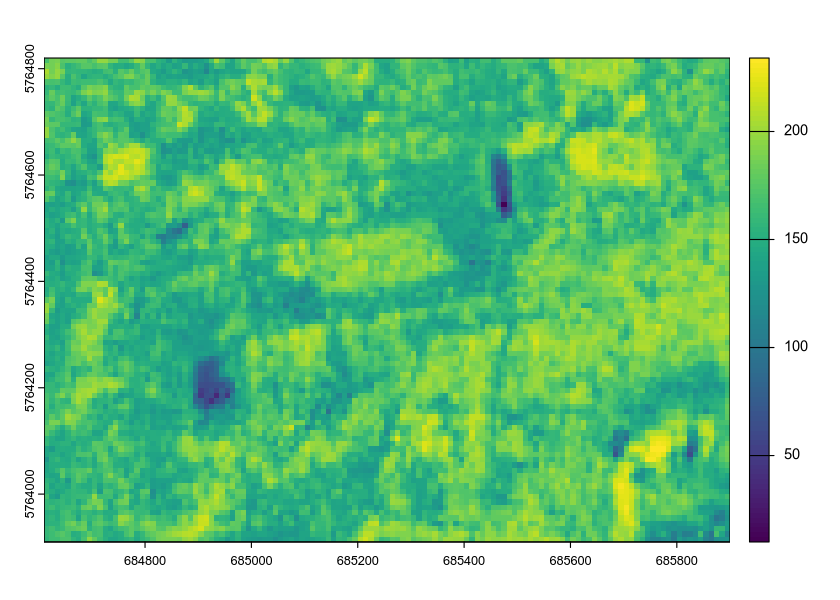

In [9]:
plot(mydata)

## 3. Dates without data

Not every layer is available for every date. When no coverage exists for the requested date, `gm_get()` stops with the message returned by the server (and does not leave a broken file behind):

In [10]:
missing_date <- replace(myparams, "date", "20251001")
result <- tryCatch(gm_get(url = gm_url(option = "NDVI", params = missing_date),
                          out_path = file.path(tempdir(), "ndvi_20251001.tif")),
                   error = function(e) conditionMessage(e))
print(result)

[1] "GroenMonitor request failed (HTTP 404): Could not locate coverage groenmonitor__ndvi_20251001"
